In [1]:
# from visualize_fp import plot_focalplane_primecam
from astropy.table import QTable
from toast.instrument import Focalplane
import matplotlib.pyplot as plt
import astropy.units as u
import h5py

In [2]:
from plotting_func import plot_eorspec_annuli

In [3]:
!tree ./fpi_data/fchl_h5/chnl_350/

./fpi_data/fchl_h5/chnl_350/
├── step210
│   └── f350_step210_d159_dettable.h5
├── step216
│   └── f350_step216_d179_dettable.h5
├── step222
│   └── f350_step222_d245_dettable.h5
└── step228
    └── f350_step228_d292_dettable.h5

4 directories, 4 files


In [4]:
h5file_path =  "./fpi_data/fchl_h5/chnl_350/step222/f350_step222_d245_dettable.h5"
with h5py.File(h5file_path, 'r') as dets_h5file:
        # Get the first path (assuming there's only one)
        path = list(dets_h5file.keys())[0]
        print(f"Processing Path: {path}")

Processing Path: 350_step222


In [5]:
dettable_stack = QTable.read(h5file_path, path=path) 
len(dettable_stack)

245

In [6]:
dettable_stack[:10]

name,wname,wtype,quat,psi_pol,gamma,fwhm,psd_fmin,psd_fknee,psd_alpha,psd_net,bandcenter,bandwidth,freq_channel,fpi_step,annuli_name
,,,,rad,rad,arcmin,Hz,Hz,,K s(1/2),GHz,GHz,,,
bytes30,bytes4,bytes4,float64[4],float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,bytes8,bytes8
eorspec_0259_hfa-350,hfa,hfa,0.002213366693595409 .. 0.707099326294062,0.0,1.047195280297181,0.62,0.001,1.0,1.0,0.00017547,350.77,3.49,350,step222,A5
eorspec_0260_hfa-350,hfa,hfa,0.002277204861691879 .. 0.7070991685078873,0.0,1.0471952802970161,0.62,0.001,1.0,1.0,0.00017547,350.77,3.49,350,step222,A5
eorspec_0261_hfa-350,hfa,hfa,0.002341043011013312 .. 0.7070990049583062,0.0,1.0471952802968154,0.62,0.001,1.0,1.0,0.00017547,350.77,3.49,350,step222,A5
eorspec_0262_hfa-350,hfa,hfa,0.002404881143120704 .. 0.7070988356453172,0.0,1.0471952802965765,0.62,0.001,1.0,1.0,0.00017547,350.77,3.49,350,step222,A5
eorspec_0263_hfa-350,hfa,hfa,0.0024687192595750466 .. 0.7070986605689171,0.0,1.0471952802963016,0.62,0.001,1.0,1.0,0.00017547,350.77,3.49,350,step222,A5
eorspec_0264_hfa-350,hfa,hfa,0.00253255736193733 .. 0.7070984797291022,0.0,1.047195280295989,0.62,0.001,1.0,1.0,0.00017547,350.77,3.49,350,step222,A5
eorspec_0265_hfa-350,hfa,hfa,0.002596395451768543 .. 0.7070982931258689,0.0,1.04719528029564,0.62,0.001,1.0,1.0,0.00017547,350.77,3.49,350,step222,A5
eorspec_0266_hfa-350,hfa,hfa,0.002660233530629674 .. 0.707098100759212,0.0,1.0471952802952535,0.62,0.001,1.0,1.0,0.00017547,350.77,3.49,350,step222,A5


Plotting FPI Step: step222


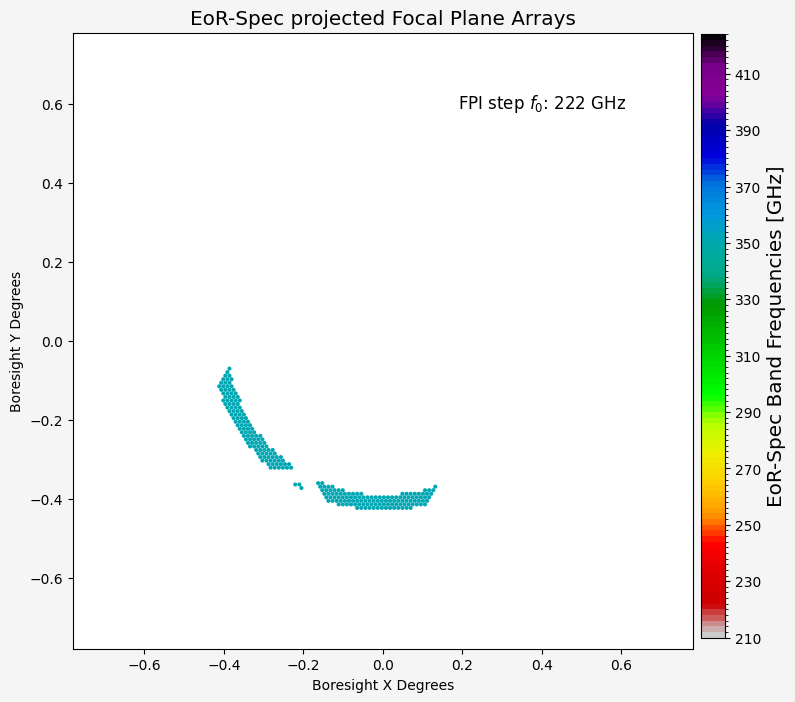

In [7]:
# Read the detector table from the HDF5 file        
dets_table = QTable.read(h5file_path, path)

# Plotting the annuli
width= 1.3 * u.degree
#width of plot set to 1.3 degrees fixed in plot_eorspec_annuli

# outfile_path = os.path.join(plots_dir, f"fp_eorspec_{path}.png")
# outfile_path = os.path.join(plots_dir, f"fp_eorspec_{path}.pdf")
fp_test =  Focalplane(
                detector_data=dets_table,
                field_of_view=1.1 * width,
                )

plot_eorspec_annuli(
    focalplane=fp_test,
    label_step=True)

plt.show()

In [ ]:
# EoR-Spec NET values based on CCAT Science paper
# [220 280 350 410] #GHz
# [ 26.89791319  41.97225879 175.46826475 497.05288767] #uK sqrt(s)

In [ ]:
# band1 230 GHz: 210 - 250 GHz
# band2 280 GHz: 260 - 300 GHz
# band3 350 GHz: 330 - 370 GHz
# band4 405 GHz: 385 - 425 GHz

## Water Vapor lines at 325 GHz and 380 GHz

In [11]:
fwhm_arcsec = [58, 48, 37, 33] #arcsec

In [19]:
from astropy import units as u
import numpy as np
fwhm_arcmin = np.round((fwhm_arcsec* u.arcsec).to(u.arcmin),5)
fwhm_deg = np.round((fwhm_arcmin).to(u.degree),5)
print(f"fwhm_arcsec: {fwhm_arcsec* u.arcsec}")
print(f"fwhm_arcmin: {fwhm_arcmin}")
print(f"fwhm_deg: {fwhm_deg}")

fwhm_arcsec: [58. 48. 37. 33.] arcsec
fwhm_arcmin: [0.96667 0.8     0.61667 0.55   ] arcmin
fwhm_deg: [0.01611 0.01333 0.01028 0.00917] deg


In [73]:
#---------------------------#
# To convert Jy/sr to μK #
#---------------------------#
# Ref: https://arxiv.org/pdf/astro-ph/0302223
# Eq: 17 conversion factor from Jy sr−1 to µK
# g(ν) = (24.76 Jy μK^−1 sr^−1 )^−1 [(sinh x/2)/x^2 ]^2
# where x = ~  ν/(56.78 GHz)

#For table 1c 
import numpy as np

# Define the constants
conversion_factor = 24.76  

# Frequencies in GHz
frequencies_GHz = np.array([220, 280, 350, 410])

# NEI values from the table in Jy sr^-1 sqrt(s)
NEI_values = np.array([13000, 18000, 53000, 98000]) #CCAT # Current vals used
# NEI_values = np.array([12900, 16600, 30600, 61500]) # Choi2020 #not used

# Calculate x for each frequency
x_values = frequencies_GHz / 56.78

# Calculate the hyperbolic sine term
sinh_term = (np.sinh(x_values / 2) / x_values**2)**2

# Calculate g(nu)
g_nu = (1 / conversion_factor) * sinh_term # μK /(Jy sr^-1)

# Calculate NET from NEI and g(nu)
# Multiply by g_nu to go from Jy/sr to μK
NET_values_calc = NEI_values * (g_nu) 

print(frequencies_GHz)
print(np.round(NET_values_calc,2))  #μK √s

[220 280 350 410]
[ 26.9   41.97 175.47 497.05]


In [ ]:
#-------------------------------------------#

In [ ]:
#To gen focalplanes
# 1. Run fp_dettable.py 
# 2. Run fpi_step.py
# 3. Run write_annuli_fchl_h5.py
# 4. Run write_annuli_fpistep_h5.py
# 5. Run plot_fpisteps.py